# Model Comparison

This notebook will compare the performance and robustness of four models on multi-label classification

## Import libraries

In [56]:
import os
import torch
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tqdm
from collections import defaultdict
from scipy import stats

from sklearn.metrics import (
    f1_score, accuracy_score, brier_score_loss,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    matthews_corrcoef, confusion_matrix,
    classification_report, log_loss
)

from src.data import load_and_prepare_datasets
from src.utils import load_model, load_finetuning_model
from src.gaussian_processes.prediction import predict_with_uncertainty
from src.finetuning.prediction import predict_with_scores

## Configuration

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# ── Plotting style ──────────────────────────────────────────────────────────
PALETTE = {
    'GP':       '#4C72B0',
    'DISTILBERT':'#DD8452',
    'GP_FT':    '#55A868',
    'GP_FT_W':  '#C44E52',
}
MODEL_LABELS = {
    'GP':       'GP (frozen)',
    'DISTILBERT':'DistilBERT baseline',
    'GP_FT':    'GP + Fine-tuned',
    'GP_FT_W':  'GP + Fine-tuned + Weights',
}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

Using device: cuda


In [58]:
# --- Gaussian Process models (frozen encoder) ---
model_gp, tokenizer_gp = load_model("models/gp/best", device=device)
model_gp.eval()

# --- DistilBERT baseline (no GP) ---
model_distilbert, tokenizer_distilbert = load_finetuning_model("models/finetuning_baseline/best", device=device)
model_distilbert.eval()

# --- GP + fine-tuned encoder ---
model_gp_ft, tokenizer_gp_ft = load_model("models/gp_finetune_v2/best", device=device)
model_gp_ft.eval()

# --- GP + fine-tuned encoder + class weights ---
model_gp_ft_w, tokenizer_gp_ft_w = load_model("models/gp_finetune_weights/best", device=device)
model_gp_ft_w.eval()

print("All models loaded.")

[INFO] Loading model from: models/gp/best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models/gp/best\pytorch_model.bin
[INFO] Model loaded successfully.
[INFO] Loading finetuning model from: models/finetuning_baseline/best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models/gp_finetune_v2/best\pytorch_model.bin
[INFO] Model loaded successfully.
[INFO] Loading model from: models/gp_finetune_weights/best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models/gp_finetune_weights/best\pytorch_model.bin
[INFO] Model loaded successfully.
All models loaded.


In [59]:
datasets, id2label = load_and_prepare_datasets(tokenizer=tokenizer_gp_ft)
test_set = datasets["test"]
print(f"Test set size: {len(test_set):,}")

Jigsaw dataset already exists. Skipping download.


Map:   0%|          | 0/129251 [00:00<?, ? examples/s]

Map:   0%|          | 0/14362 [00:00<?, ? examples/s]

Map:   0%|          | 0/15958 [00:00<?, ? examples/s]

Test set size: 15,958


## Run inference

In [60]:
CACHE_PATH = "results.json"

def run_inference_gp(model, tokenizer, test_set, device, desc="GP"):
    all_probs, all_stds, all_true = [], [], []
    for sample in tqdm.tqdm(test_set, desc=desc):
        true_labels = sample["labels"].numpy().tolist()
        text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
        result = predict_with_uncertainty(
            model, tokenizer, text, id2label, device=device, threshold=0.5
        )
        probs = [p for _, p, _ in result["all_scores"]]
        stds  = [s for _, _, s in result["all_scores"]]
        all_probs.append(probs)
        all_stds.append(stds)
        all_true.append(true_labels)
    return np.array(all_probs), np.array(all_stds), np.array(all_true)

def run_inference_distilbert(model, tokenizer, test_set, device, desc="DistilBERT"):
    all_probs, all_true = [], []
    for sample in tqdm.tqdm(test_set, desc=desc):
        true_labels = sample["labels"].numpy().tolist()
        text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
        result = predict_with_scores(
            model, tokenizer, text, id2label, device=device, threshold=0.5
        )
        probs = [p for _, p in result["raw_probs"]]
        all_probs.append(probs)
        all_true.append(true_labels)
    return np.array(all_probs), np.zeros_like(np.array(all_probs)), np.array(all_true)

def save_results(results, path):
    serializable = {
        model_key: {
            "probs":  data["probs"].tolist(),
            "stds":   data["stds"].tolist(),
            "y_true": data["y_true"].tolist(),
        }
        for model_key, data in results.items()
    }
    with open(path, "w") as f:
        json.dump(serializable, f)
    print(f"Saved to {path}.")

def load_results(path):
    with open(path) as f:
        raw = json.load(f)
    return {
        model_key: {
            "probs":  np.array(data["probs"]),
            "stds":   np.array(data["stds"]),
            "y_true": np.array(data["y_true"]),
        }
        for model_key, data in raw.items()
    }

# ── Run or load ───────────────────────────────────────────────────────────
if os.path.exists(CACHE_PATH):
    print(f"Cache found — loading from {CACHE_PATH} (skip inference).")
    results = load_results(CACHE_PATH)
else:
    print("No cache found — running inference...")
    results = {}
    probs_gp,  stds_gp,  y_true = run_inference_gp(model_gp, tokenizer_gp, test_set, device, desc="GP (frozen)")
    results['GP']       = {'probs': probs_gp,  'stds': stds_gp,  'y_true': y_true}

    probs_db, stds_db, _ = run_inference_distilbert(model_distilbert, tokenizer_distilbert, test_set, device, desc="DistilBERT")
    results['DISTILBERT'] = {'probs': probs_db, 'stds': stds_db,  'y_true': y_true}

    probs_ft,  stds_ft,  _ = run_inference_gp(model_gp_ft, tokenizer_gp_ft, test_set, device, desc="GP + Fine-tuned")
    results['GP_FT']    = {'probs': probs_ft,  'stds': stds_ft,  'y_true': y_true}

    probs_fw,  stds_fw,  _ = run_inference_gp(model_gp_ft_w, tokenizer_gp_ft_w, test_set, device, desc="GP + FT + Weights")
    results['GP_FT_W']  = {'probs': probs_fw,  'stds': stds_fw,  'y_true': y_true}

    save_results(results, CACHE_PATH)

print("Inference complete.")

Cache found — loading from results.json (skip inference).
Inference complete.


In [61]:
import os
path_images = "images"
os.makedirs(path_images, exist_ok=True)

### Optimal threshold for each model

In [62]:
def find_optimal_threshold(y_true_col, probs_col, metric='f1', thresholds=np.arange(0.05, 0.96, 0.05)):
    """
    Sweep thresholds and return the one maximising F1 for a single label.
    Returns (best_threshold, best_score, scores_array).
    """
    scores = []
    for t in thresholds:
        y_pred = (probs_col >= t).astype(int)
        if metric == 'f1':
            s = f1_score(y_true_col, y_pred, zero_division=0)
        elif metric == 'mcc':
            s = matthews_corrcoef(y_true_col, y_pred)
        scores.append(s)
    scores = np.array(scores)
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx], scores


THRESHOLDS = np.arange(0.05, 0.96, 0.05)
threshold_results = {}

for model_key, data in results.items():
    threshold_results[model_key] = {}
    for i, lbl in enumerate(LABEL_COLS):
        best_t, best_f1, sweep = find_optimal_threshold(
            data['y_true'][:, i], data['probs'][:, i], metric='f1', thresholds=THRESHOLDS
        )
        threshold_results[model_key][lbl] = {
            'best_threshold': best_t,
            'best_f1': best_f1,
            'sweep': sweep,
        }

# Print summary table
rows = []
for model_key in results:
    row = {'Model': MODEL_LABELS[model_key]}
    for lbl in LABEL_COLS:
        t   = threshold_results[model_key][lbl]['best_threshold']
        f1  = threshold_results[model_key][lbl]['best_f1']
        row[lbl] = f"{t:.2f} (F1={f1:.3f})"
    rows.append(row)

df_thresh = pd.DataFrame(rows).set_index('Model')
print("=== Optimal Threshold per Model & Label (maximising F1) ===")
display(df_thresh)

=== Optimal Threshold per Model & Label (maximising F1) ===


,toxic,severe_toxic,obscene,threat,insult,identity_hate
Model,,,,,,
GP (frozen),0.30 (F1=0.743),0.25 (F1=0.465),0.35 (F1=0.742),0.10 (F1=0.414),0.20 (F1=0.669),0.25 (F1=0.455)
DistilBERT baseline,0.30 (F1=0.817),0.30 (F1=0.489),0.65 (F1=0.821),0.40 (F1=0.467),0.55 (F1=0.764),0.70 (F1=0.545)
GP + Fine-tuned,0.70 (F1=0.813),0.30 (F1=0.536),0.80 (F1=0.836),0.10 (F1=0.467),0.50 (F1=0.764),0.30 (F1=0.543)
GP + Fine-tuned + Weights,0.90 (F1=0.812),0.95 (F1=0.512),0.90 (F1=0.830),0.95 (F1=0.472),0.70 (F1=0.753),0.95 (F1=0.580)


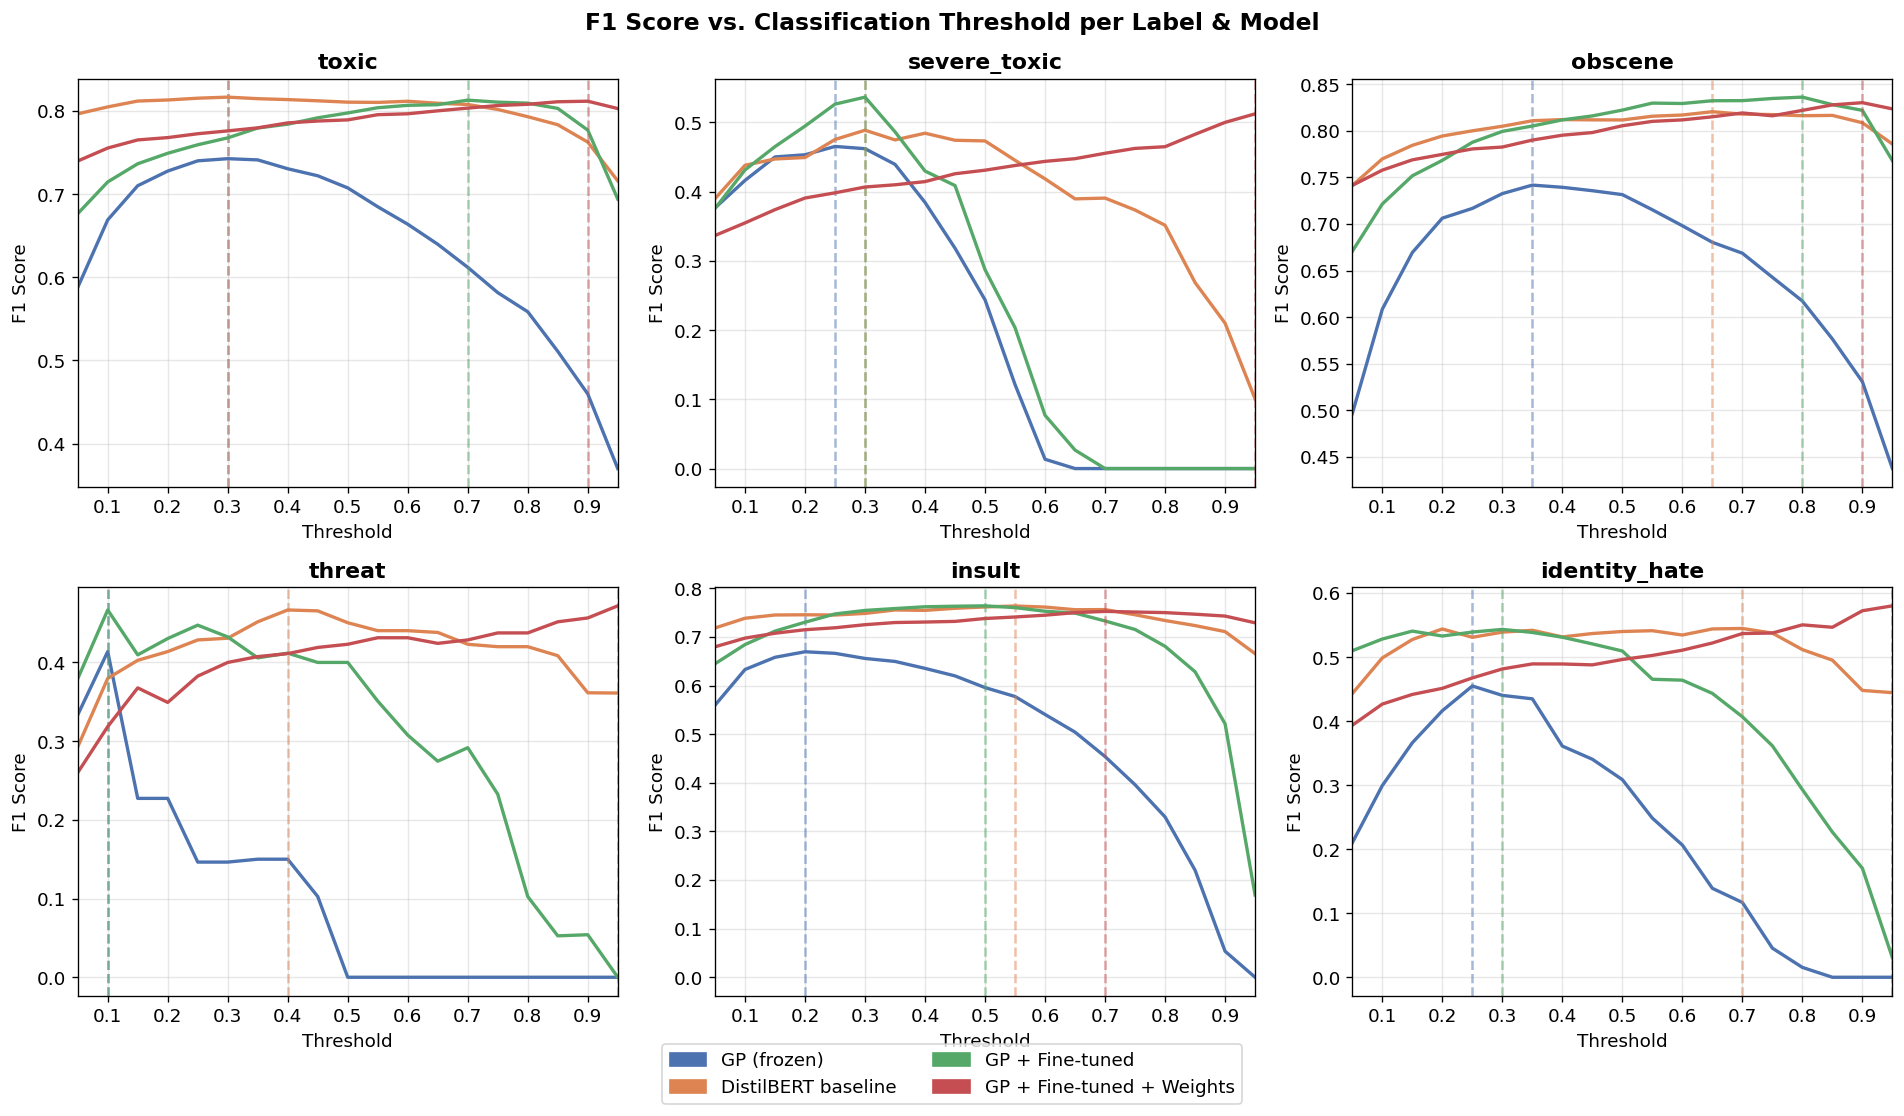

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for i, lbl in enumerate(LABEL_COLS):
    ax = axes[i]
    for model_key in results:
        sweep = threshold_results[model_key][lbl]['sweep']
        best_t = threshold_results[model_key][lbl]['best_threshold']
        best_f1 = threshold_results[model_key][lbl]['best_f1']
        ax.plot(THRESHOLDS, sweep, label=MODEL_LABELS[model_key],
                color=PALETTE[model_key], linewidth=2)
        ax.axvline(best_t, color=PALETTE[model_key], linestyle='--', alpha=0.5)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')
    ax.set_xlim(0.05, 0.95)
    ax.grid(alpha=0.3)

handles = [mpatches.Patch(color=PALETTE[k], label=MODEL_LABELS[k]) for k in results]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('F1 Score vs. Classification Threshold per Label & Model', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('threshold_sweep.png', bbox_inches='tight')
plt.show()

## Performance

In [64]:
def compute_all_metrics(model_key, data, threshold_results):
    y_true  = data['y_true']    # (N, 6)
    probs   = data['probs']     # (N, 6)
    n_labels = y_true.shape[1]

    # Build optimal-threshold predictions
    y_pred_opt = np.zeros_like(probs, dtype=int)
    for i, lbl in enumerate(LABEL_COLS):
        t = threshold_results[model_key][lbl]['best_threshold']
        y_pred_opt[:, i] = (probs[:, i] >= t).astype(int)

    # Default threshold (0.5) predictions
    y_pred_05 = (probs >= 0.5).astype(int)

    # ── Global metrics ────────────────────────────────────────────────────
    metrics = {
        'Exact Match Accuracy (0.5)': (y_pred_05 == y_true).all(axis=1).mean(),
        'Exact Match Accuracy (opt)': (y_pred_opt == y_true).all(axis=1).mean(),
        'F1 Micro (0.5)':  f1_score(y_true, y_pred_05,  average='micro',  zero_division=0),
        'F1 Macro (0.5)':  f1_score(y_true, y_pred_05,  average='macro',  zero_division=0),
        'F1 Micro (opt)':  f1_score(y_true, y_pred_opt, average='micro',  zero_division=0),
        'F1 Macro (opt)':  f1_score(y_true, y_pred_opt, average='macro',  zero_division=0),
        'ROC-AUC (macro)': roc_auc_score(y_true, probs, average='macro'),
        'Log loss': log_loss(y_true, probs),
        'PR-AUC (macro)':  average_precision_score(y_true, probs, average='macro'),
        'Brier (macro)':   np.mean([brier_score_loss(y_true[:, i], probs[:, i])
                                    for i in range(n_labels)]),
        'MCC (macro, opt)': np.mean([matthews_corrcoef(y_true[:, i], y_pred_opt[:, i])
                                     for i in range(n_labels)]),
    }

    # ── Per-label metrics (at opt threshold) ─────────────────────────────
    per_label = {}
    for i, lbl in enumerate(LABEL_COLS):
        t   = threshold_results[model_key][lbl]['best_threshold']
        yp  = y_pred_opt[:, i]
        yt  = y_true[:, i]
        ypr = probs[:, i]
        per_label[lbl] = {
            'threshold':   t,
            'accuracy':    accuracy_score(yt, yp),
            'f1':          f1_score(yt, yp, zero_division=0),
            'brier':       brier_score_loss(yt, ypr),
            'roc_auc':     roc_auc_score(yt, ypr),
            'pr_auc':      average_precision_score(yt, ypr),
            'mcc':         matthews_corrcoef(yt, yp),
        }

    return metrics, per_label, y_pred_opt


all_metrics   = {}
all_per_label = {}
all_preds_opt = {}

for model_key, data in results.items():
    m, pl, yp = compute_all_metrics(model_key, data, threshold_results)
    all_metrics[model_key]   = m
    all_per_label[model_key] = pl
    all_preds_opt[model_key] = yp

# Summary table
df_global = pd.DataFrame(all_metrics, index=all_metrics['GP'].keys())
df_global.columns = [MODEL_LABELS[k] for k in df_global.columns]
print("=== Global Metrics ===")
display(df_global.style.format("{:.4f}").highlight_max(axis=1, color='#d4edda').highlight_min(axis=1, color='#f8d7da'))

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


=== Global Metrics ===


,GP (frozen),DistilBERT baseline,GP + Fine-tuned,GP + Fine-tuned + Weights
Exact Match Accuracy (0.5),0.9157,0.9229,0.9173,0.9054
Exact Match Accuracy (opt),0.9066,0.9217,0.9244,0.9220
F1 Micro (0.5),0.6561,0.7685,0.7709,0.7358
F1 Macro (0.5),0.4312,0.6413,0.5967,0.6138
F1 Micro (opt),0.6950,0.7725,0.7798,0.7713
F1 Macro (opt),0.5813,0.6501,0.6599,0.6598
ROC-AUC (macro),0.9776,0.9881,0.9877,0.9814
Log loss,0.2190,0.2097,0.1163,0.1217
PR-AUC (macro),0.5781,0.6505,0.6720,0.6394
Brier (macro),0.0152,0.0134,0.0127,0.0183


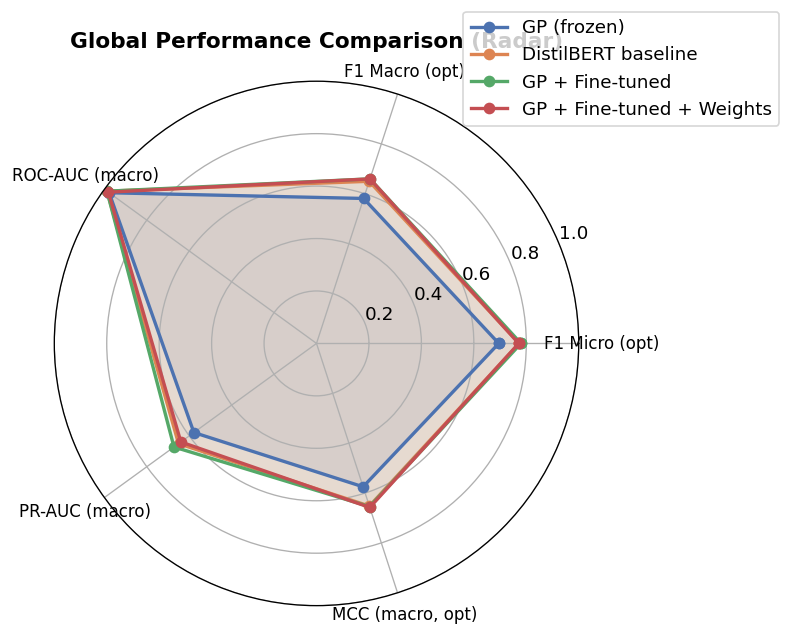

In [65]:
radar_metrics = ['F1 Micro (opt)', 'F1 Macro (opt)', 'ROC-AUC (macro)',
                 'PR-AUC (macro)', 'MCC (macro, opt)']
# For Brier we invert (lower = better) for the radar
brier_values = {k: all_metrics[k]['Brier (macro)'] for k in all_metrics}

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model_key in results:
    values = [all_metrics[model_key][m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=PALETTE[model_key],
            label=MODEL_LABELS[model_key])
    ax.fill(angles, values, alpha=0.1, color=PALETTE[model_key])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15))
ax.set_title('Global Performance Comparison (Radar)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
# plt.savefig('radar_comparison.png', bbox_inches='tight')
plt.show()

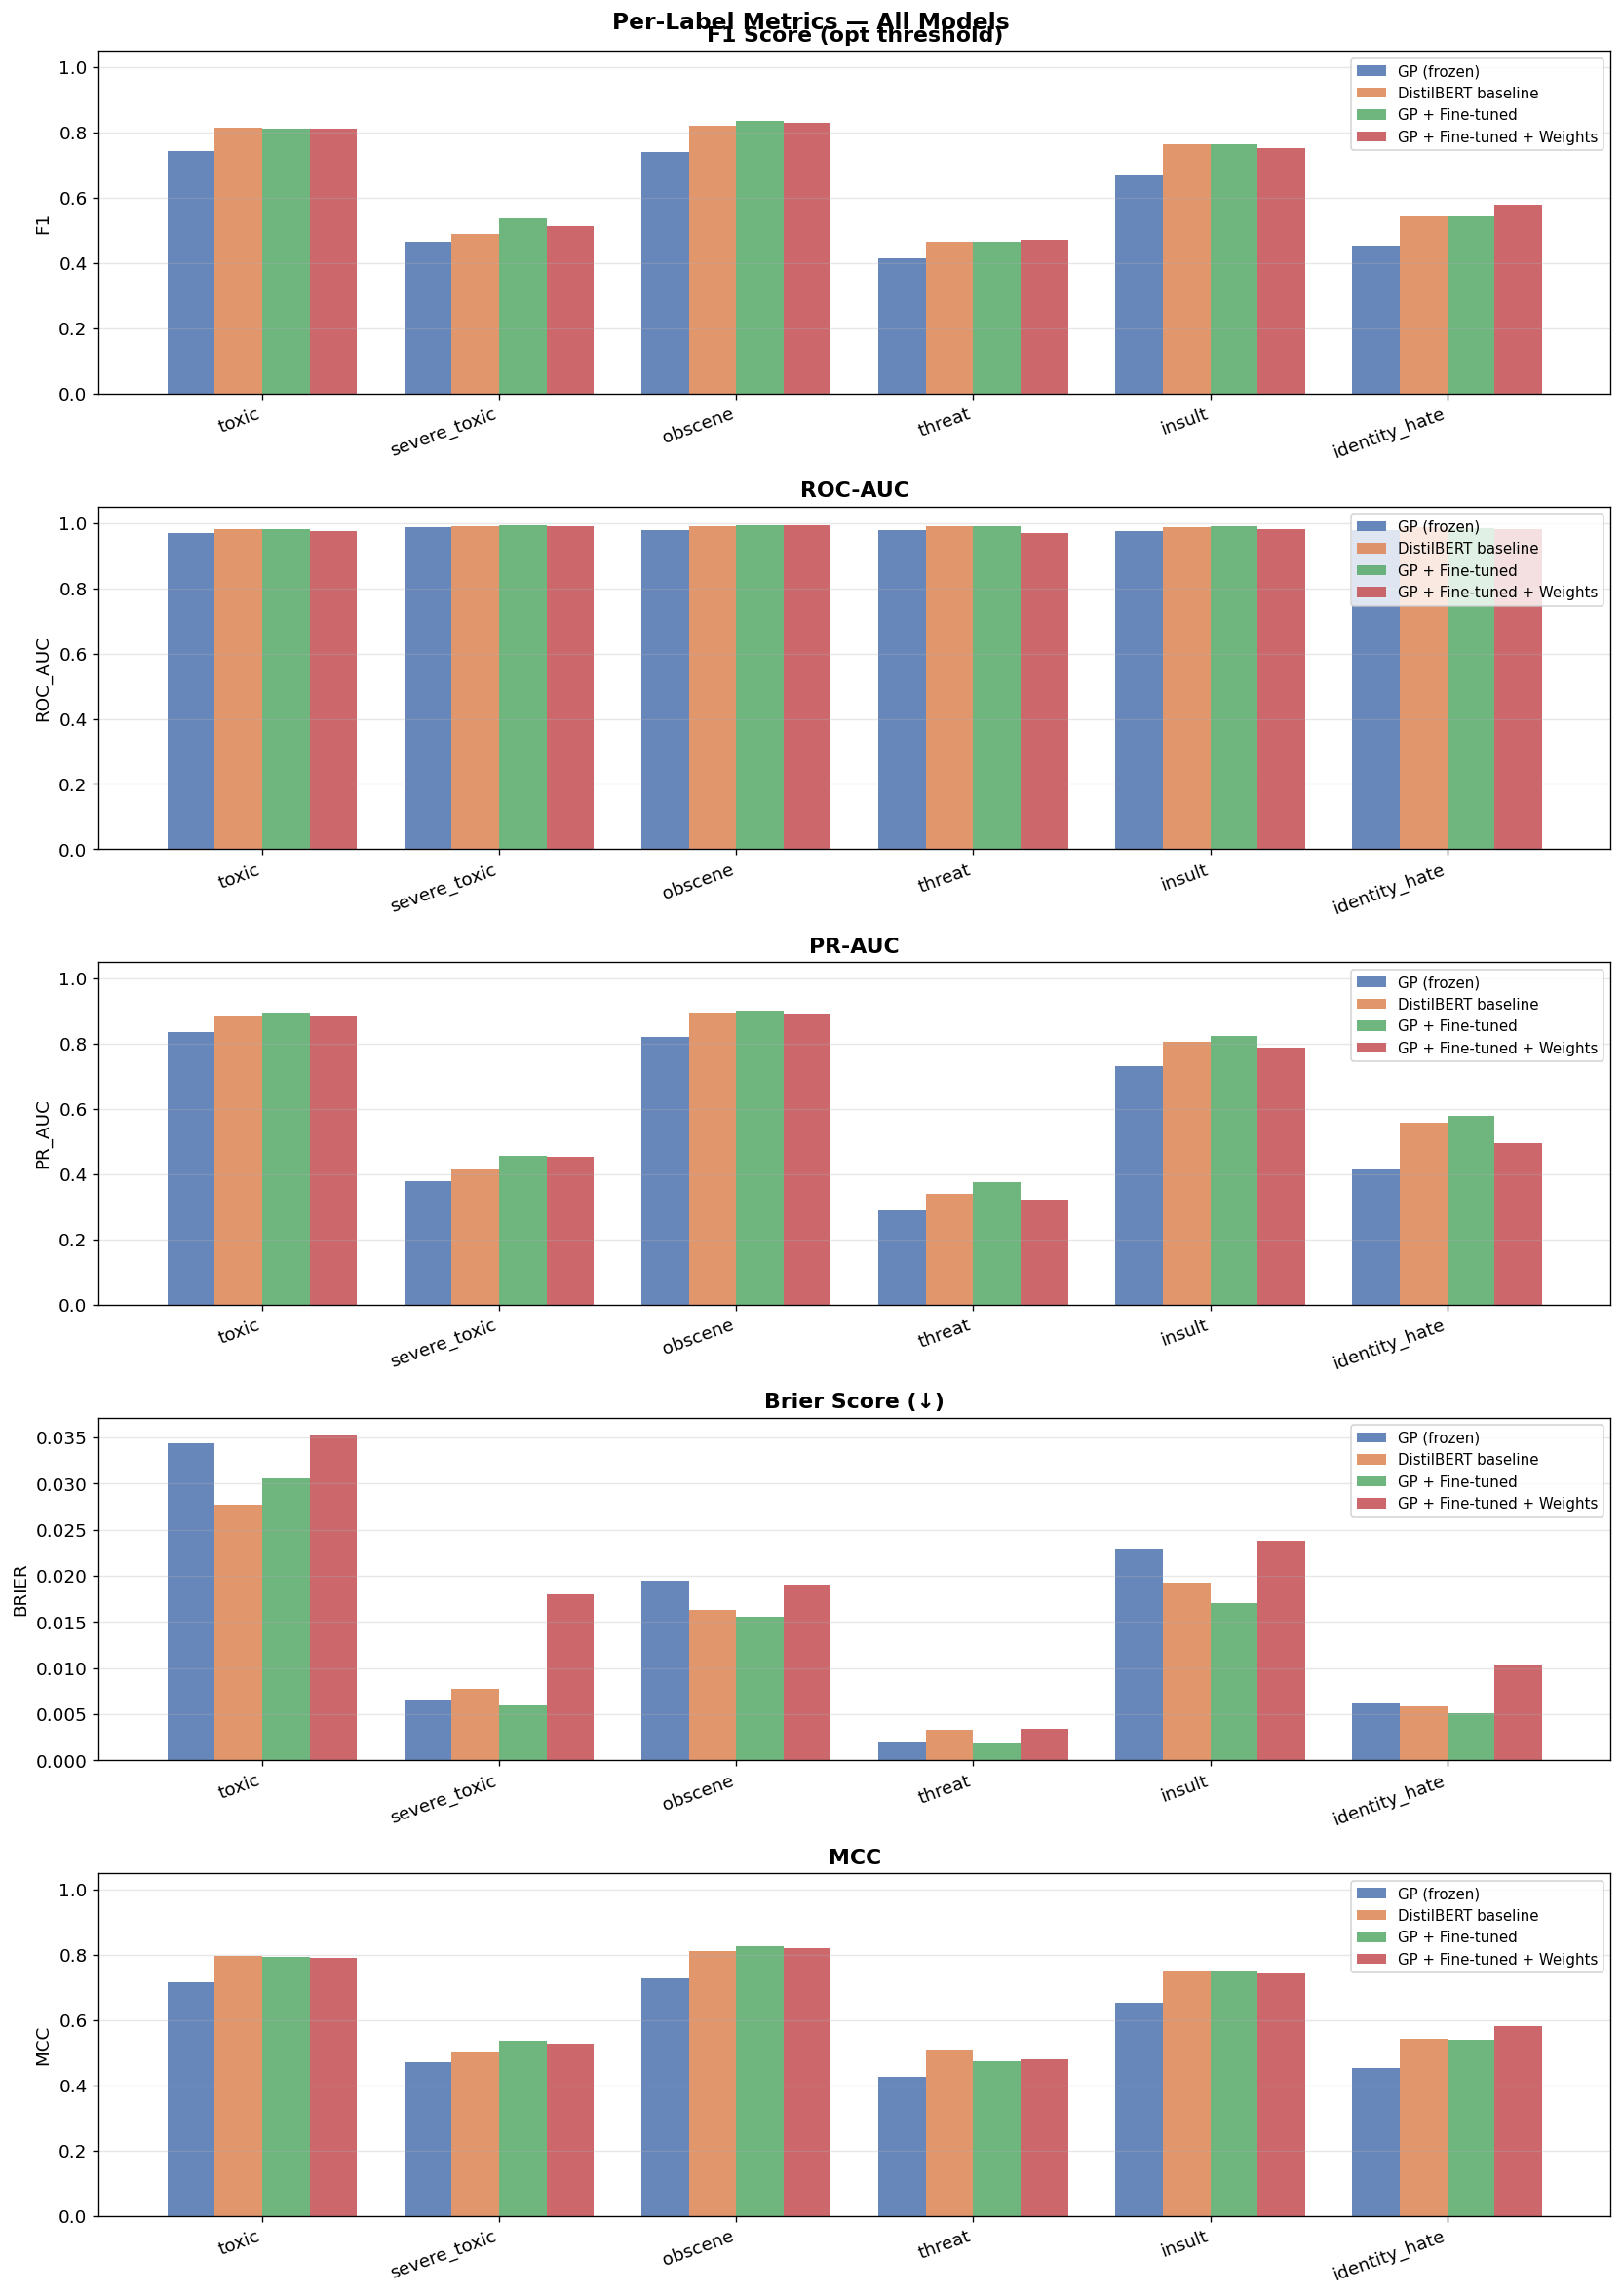

In [66]:
metric_names = ['f1', 'roc_auc', 'pr_auc', 'brier', 'mcc']
metric_titles = ['F1 Score (opt threshold)', 'ROC-AUC', 'PR-AUC', 'Brier Score (↓)', 'MCC']

fig, axes = plt.subplots(len(metric_names), 1, figsize=(14, 4 * len(metric_names)))

x = np.arange(len(LABEL_COLS))
width = 0.2
offsets = np.linspace(-0.3, 0.3, len(results))

for ax, metric, title in zip(axes, metric_names, metric_titles):
    for offset, (model_key, _) in zip(offsets, results.items()):
        values = [all_per_label[model_key][lbl][metric] for lbl in LABEL_COLS]
        bars = ax.bar(x + offset, values, width, label=MODEL_LABELS[model_key],
                      color=PALETTE[model_key], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(LABEL_COLS, rotation=20, ha='right')
    ax.set_ylabel(metric.upper())
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if metric != 'brier':
        ax.set_ylim(0, 1.05)

fig.suptitle('Per-Label Metrics — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/per_label_metrics.pdf', bbox_inches='tight')
plt.show()

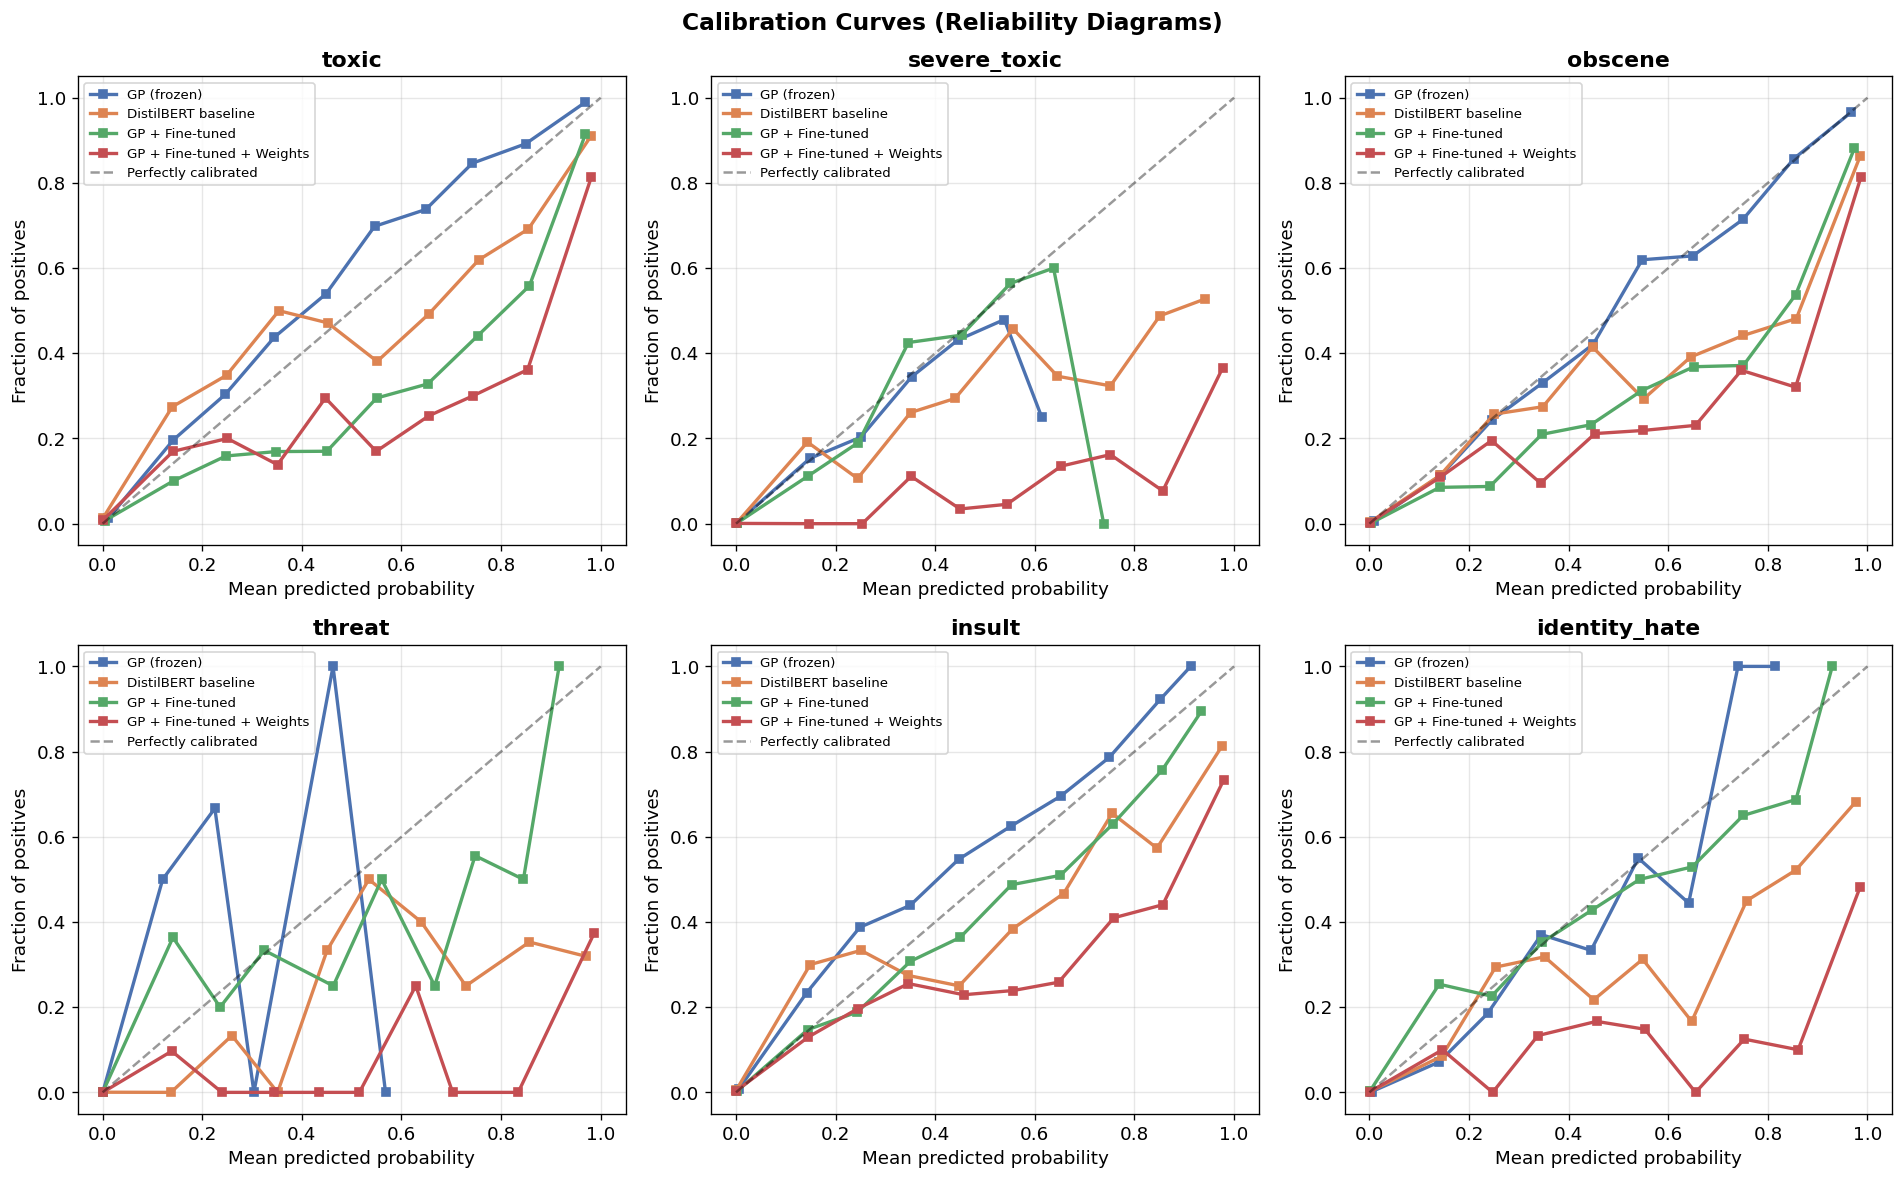

In [67]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, lbl in enumerate(LABEL_COLS):
    ax = axes[i]
    for model_key, data in results.items():
        fraction_pos, mean_pred = calibration_curve(
            data['y_true'][:, i], data['probs'][:, i], n_bins=10, strategy='uniform'
        )
        ax.plot(mean_pred, fraction_pos, 's-',
                label=MODEL_LABELS[model_key], color=PALETTE[model_key], linewidth=2, markersize=5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('calibration_curves.png', bbox_inches='tight')
plt.show()

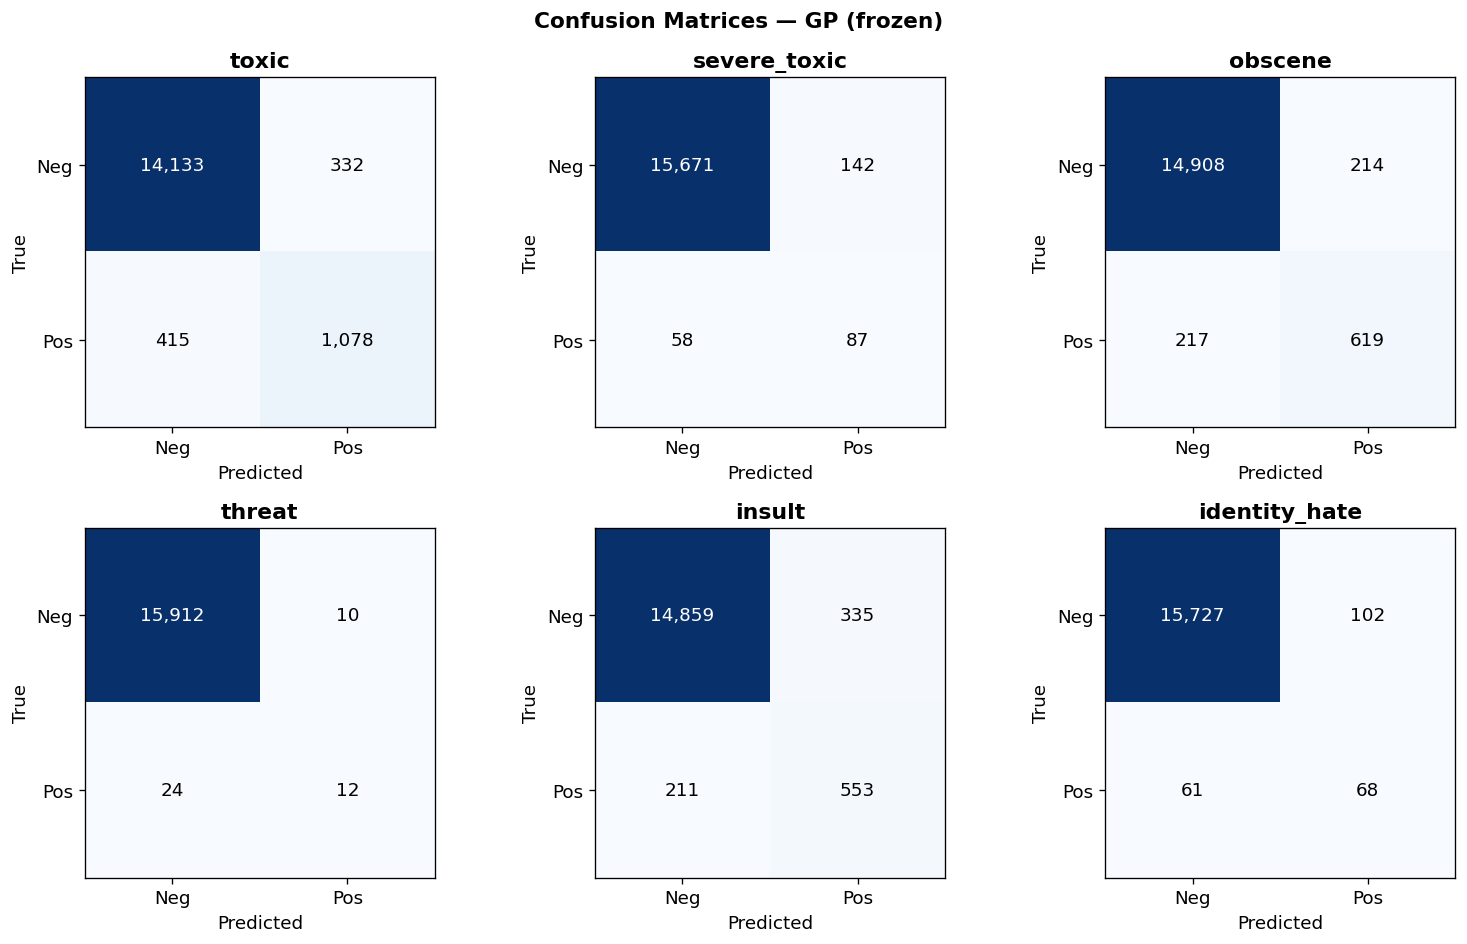

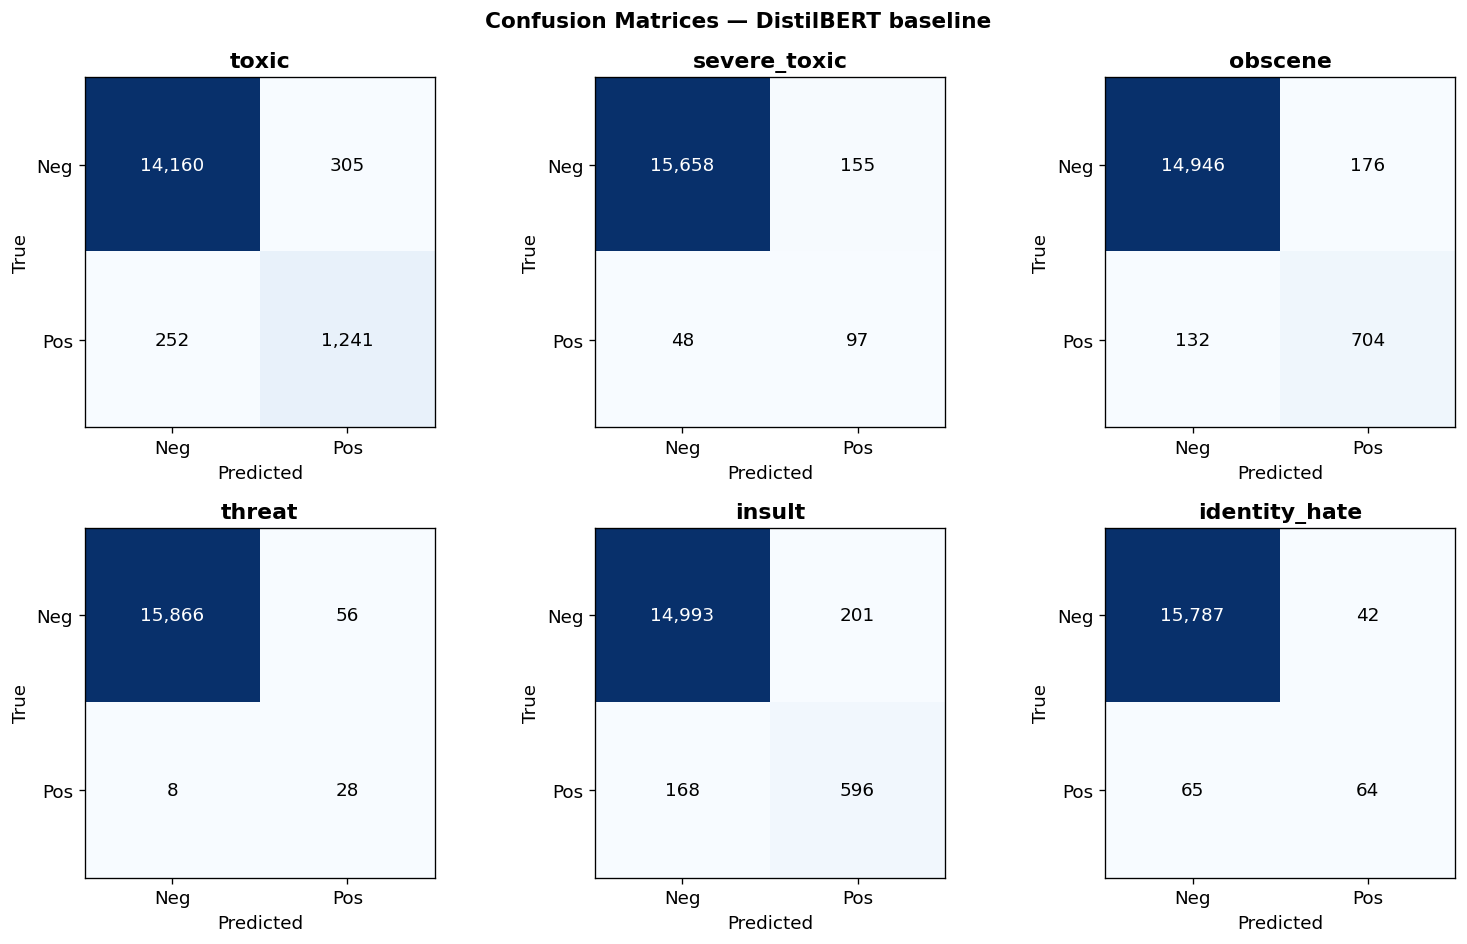

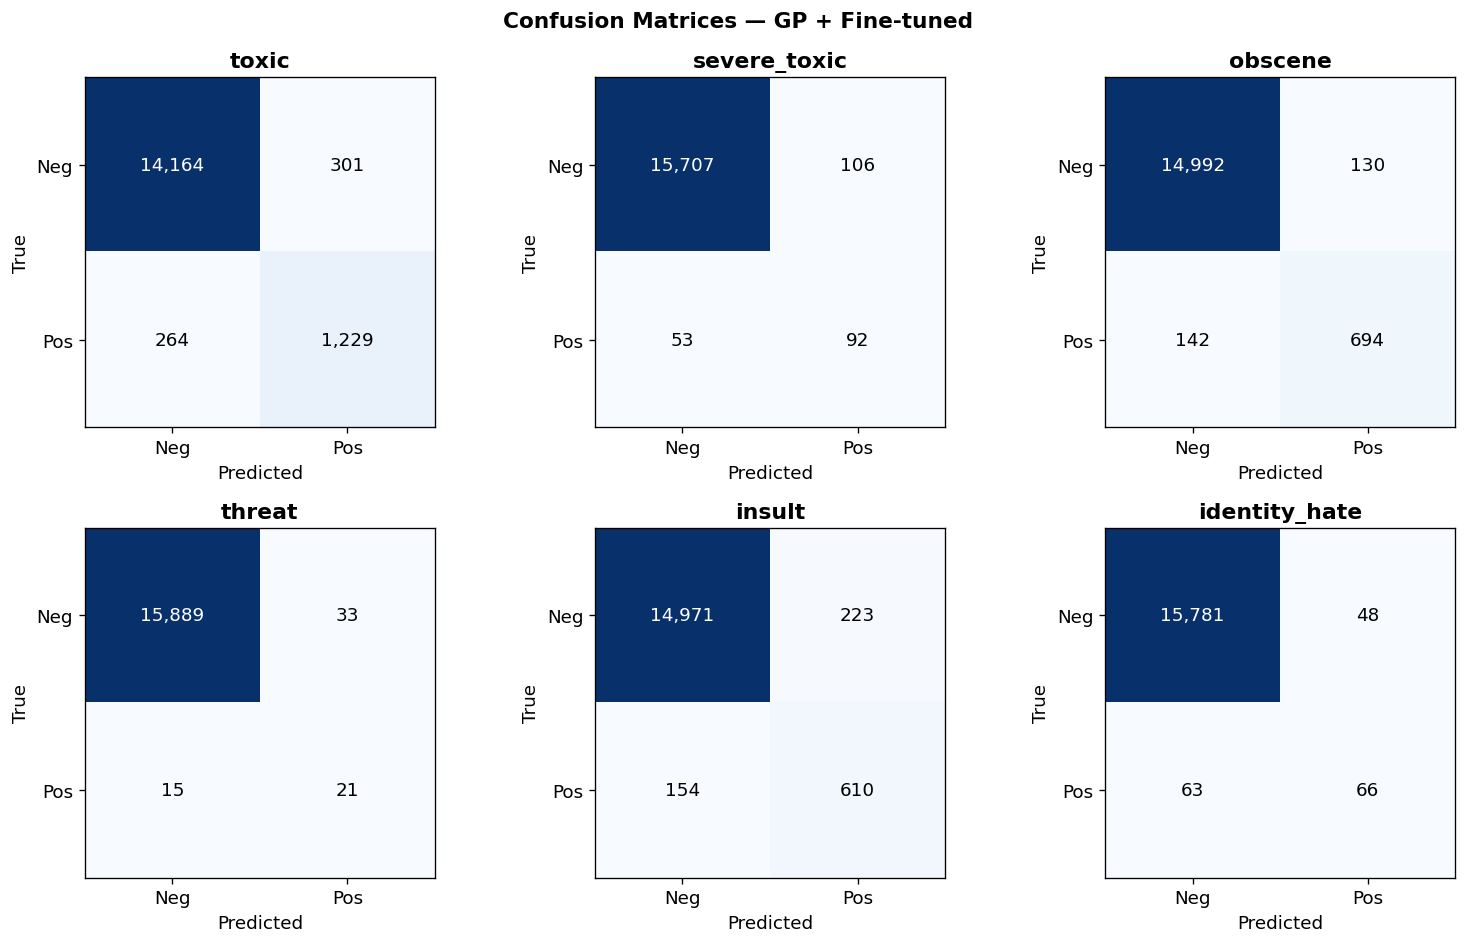

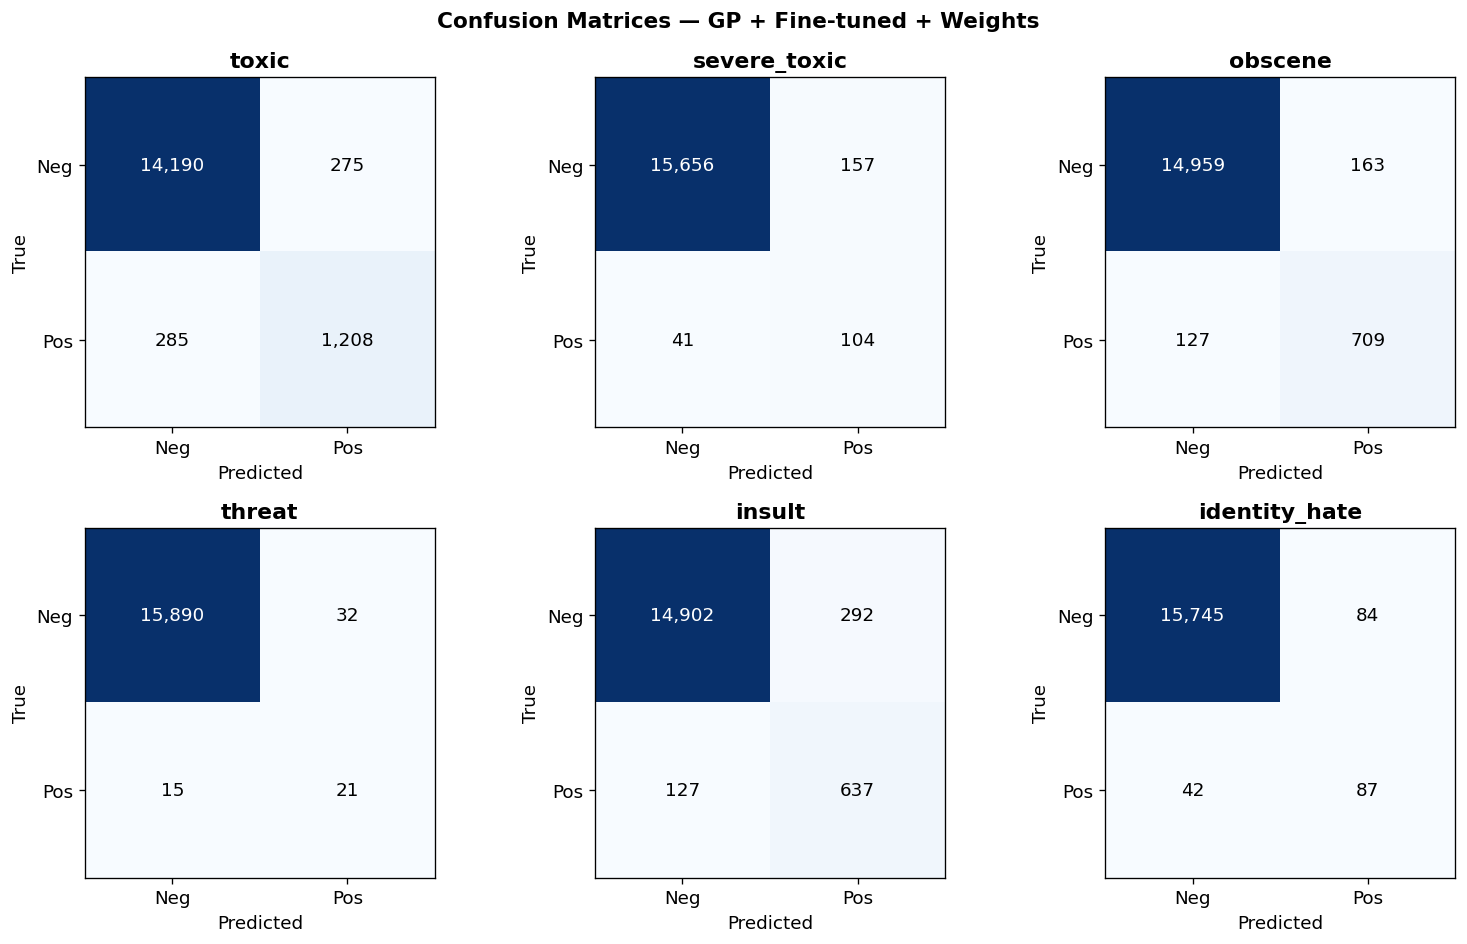

In [68]:
for model_key in results:
    y_true  = results[model_key]['y_true']
    y_pred  = all_preds_opt[model_key]

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()
    for i, (lbl, ax) in enumerate(zip(LABEL_COLS, axes)):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        im = ax.imshow(cm, cmap='Blues')
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f'{cm[r,c]:,}', ha='center', va='center',
                        color='white' if cm[r,c] > cm.max() / 2 else 'black', fontsize=11)
        ax.set_title(lbl, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    fig.suptitle(f'Confusion Matrices — {MODEL_LABELS[model_key]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(f'confusion_{model_key}.png', bbox_inches='tight')
    plt.show()

### Uncertainty analysis

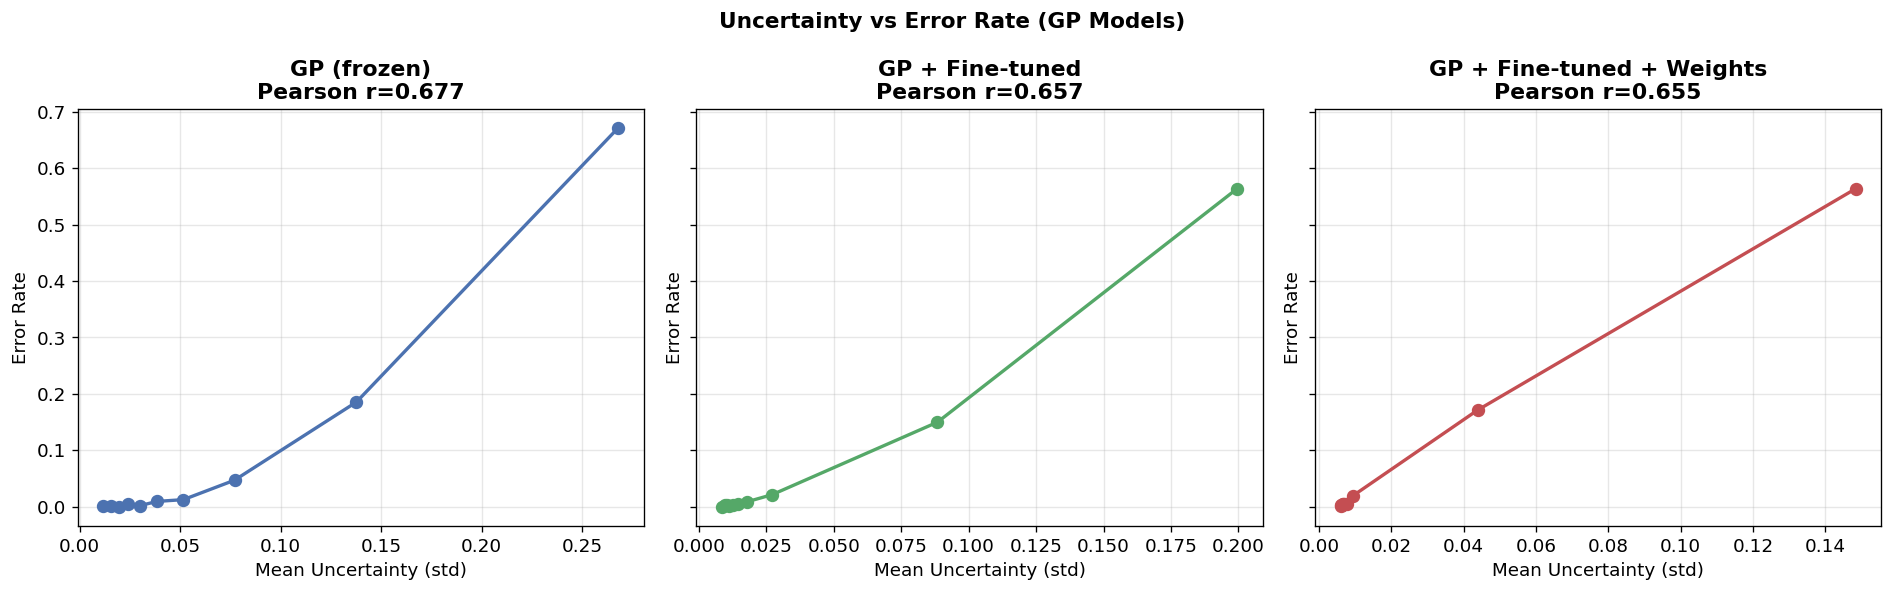

In [69]:
GP_MODELS = ['GP', 'GP_FT', 'GP_FT_W']

fig, axes = plt.subplots(1, len(GP_MODELS), figsize=(16, 5), sharey=True)

for ax, model_key in zip(axes, GP_MODELS):
    stds    = results[model_key]['stds'].mean(axis=1)   # mean std over labels
    y_true  = results[model_key]['y_true']
    y_pred  = all_preds_opt[model_key]
    correct = (y_pred == y_true).all(axis=1).astype(int)
    errors  = 1 - correct

    # Bin by uncertainty decile
    n_bins = 10
    order  = np.argsort(stds)
    bins   = np.array_split(order, n_bins)
    bin_std = [stds[b].mean() for b in bins]
    bin_err = [errors[b].mean() for b in bins]

    r = np.corrcoef(stds, errors)[0, 1]
    ax.plot(bin_std, bin_err, 'o-', color=PALETTE[model_key], linewidth=2, markersize=7)
    ax.set_title(f"{MODEL_LABELS[model_key]}\nPearson r={r:.3f}", fontweight='bold')
    ax.set_xlabel('Mean Uncertainty (std)')
    ax.set_ylabel('Error Rate')
    ax.grid(alpha=0.3)

fig.suptitle('Uncertainty vs Error Rate (GP Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('uncertainty_vs_error.png', bbox_inches='tight')
plt.show()

## Thresholds with uncertainty

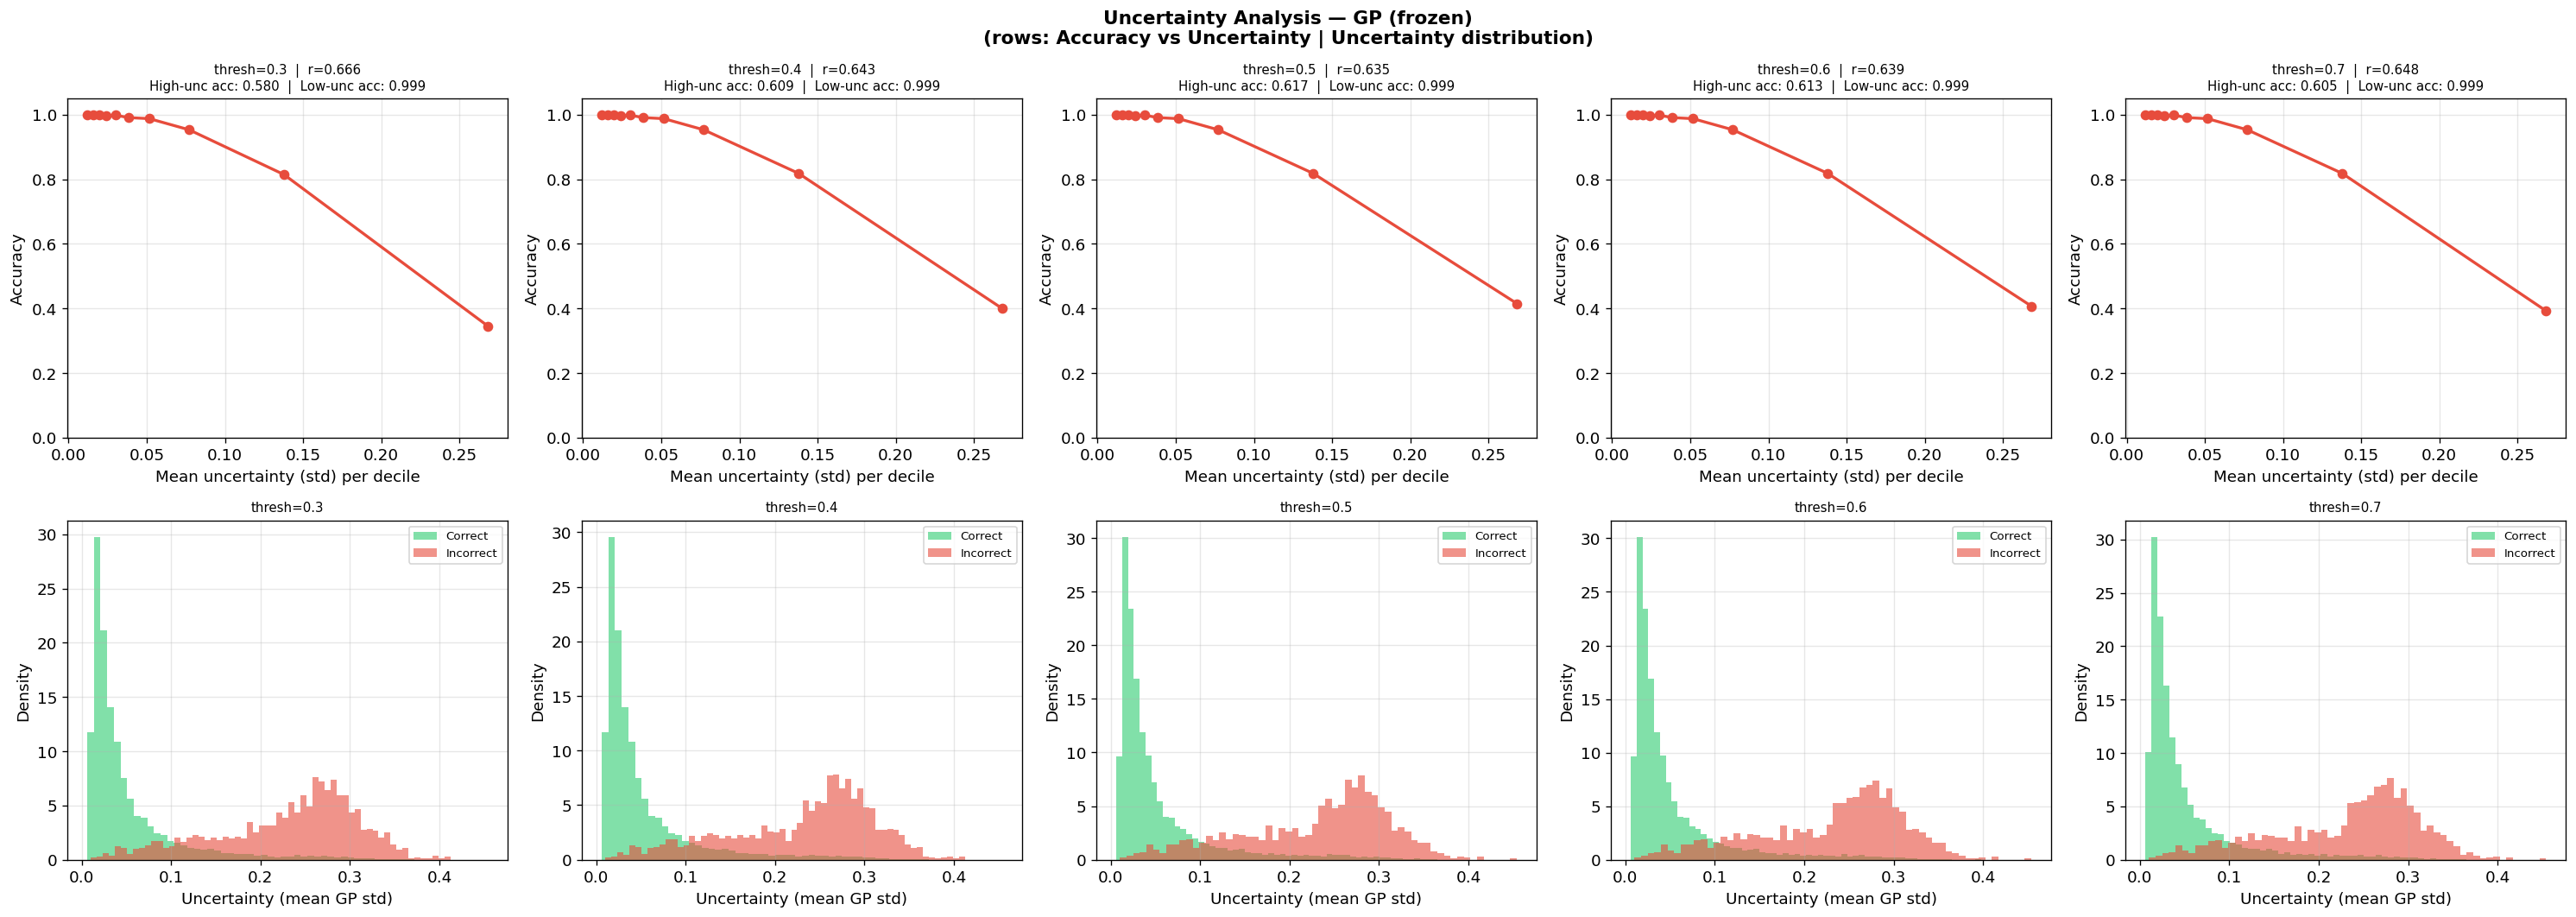

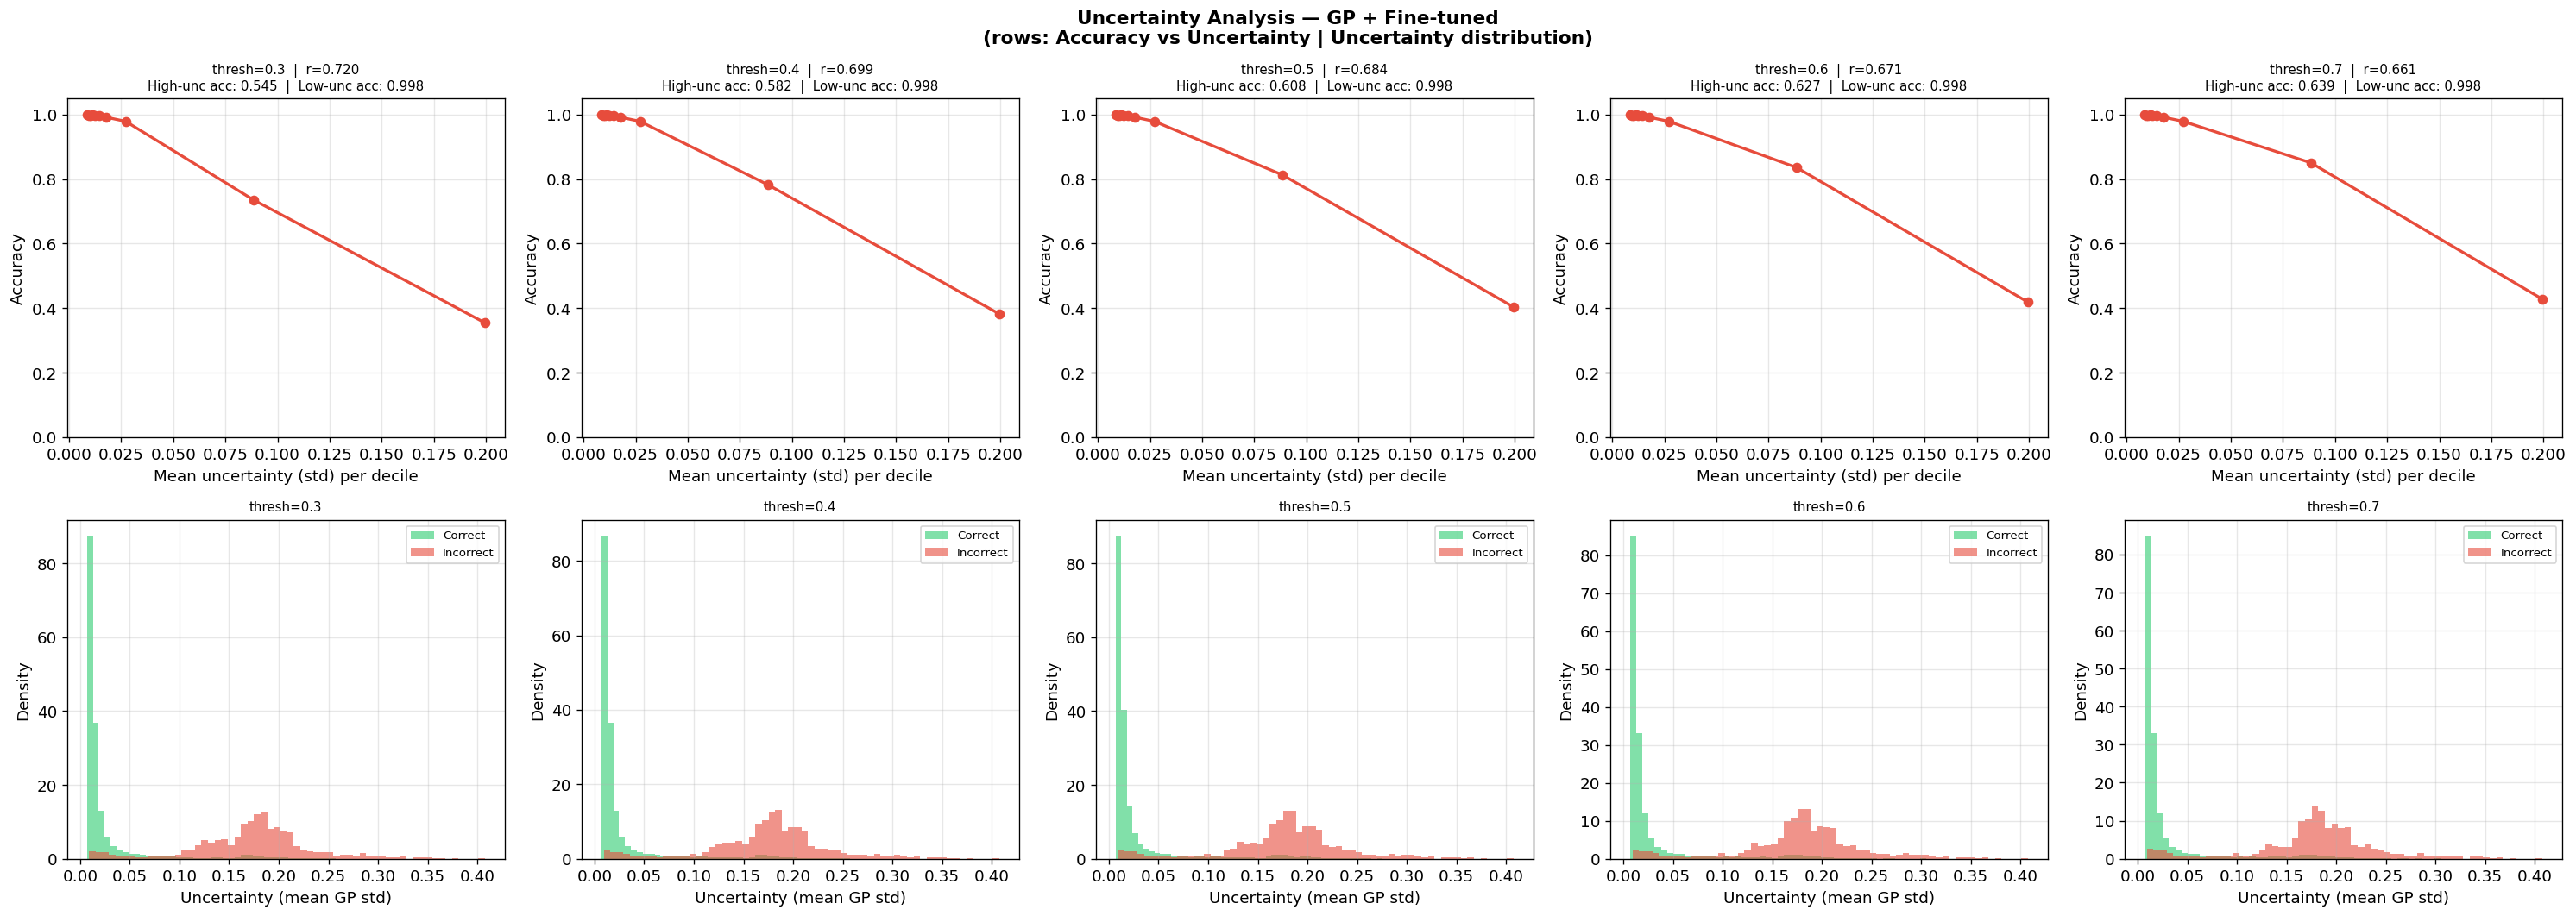

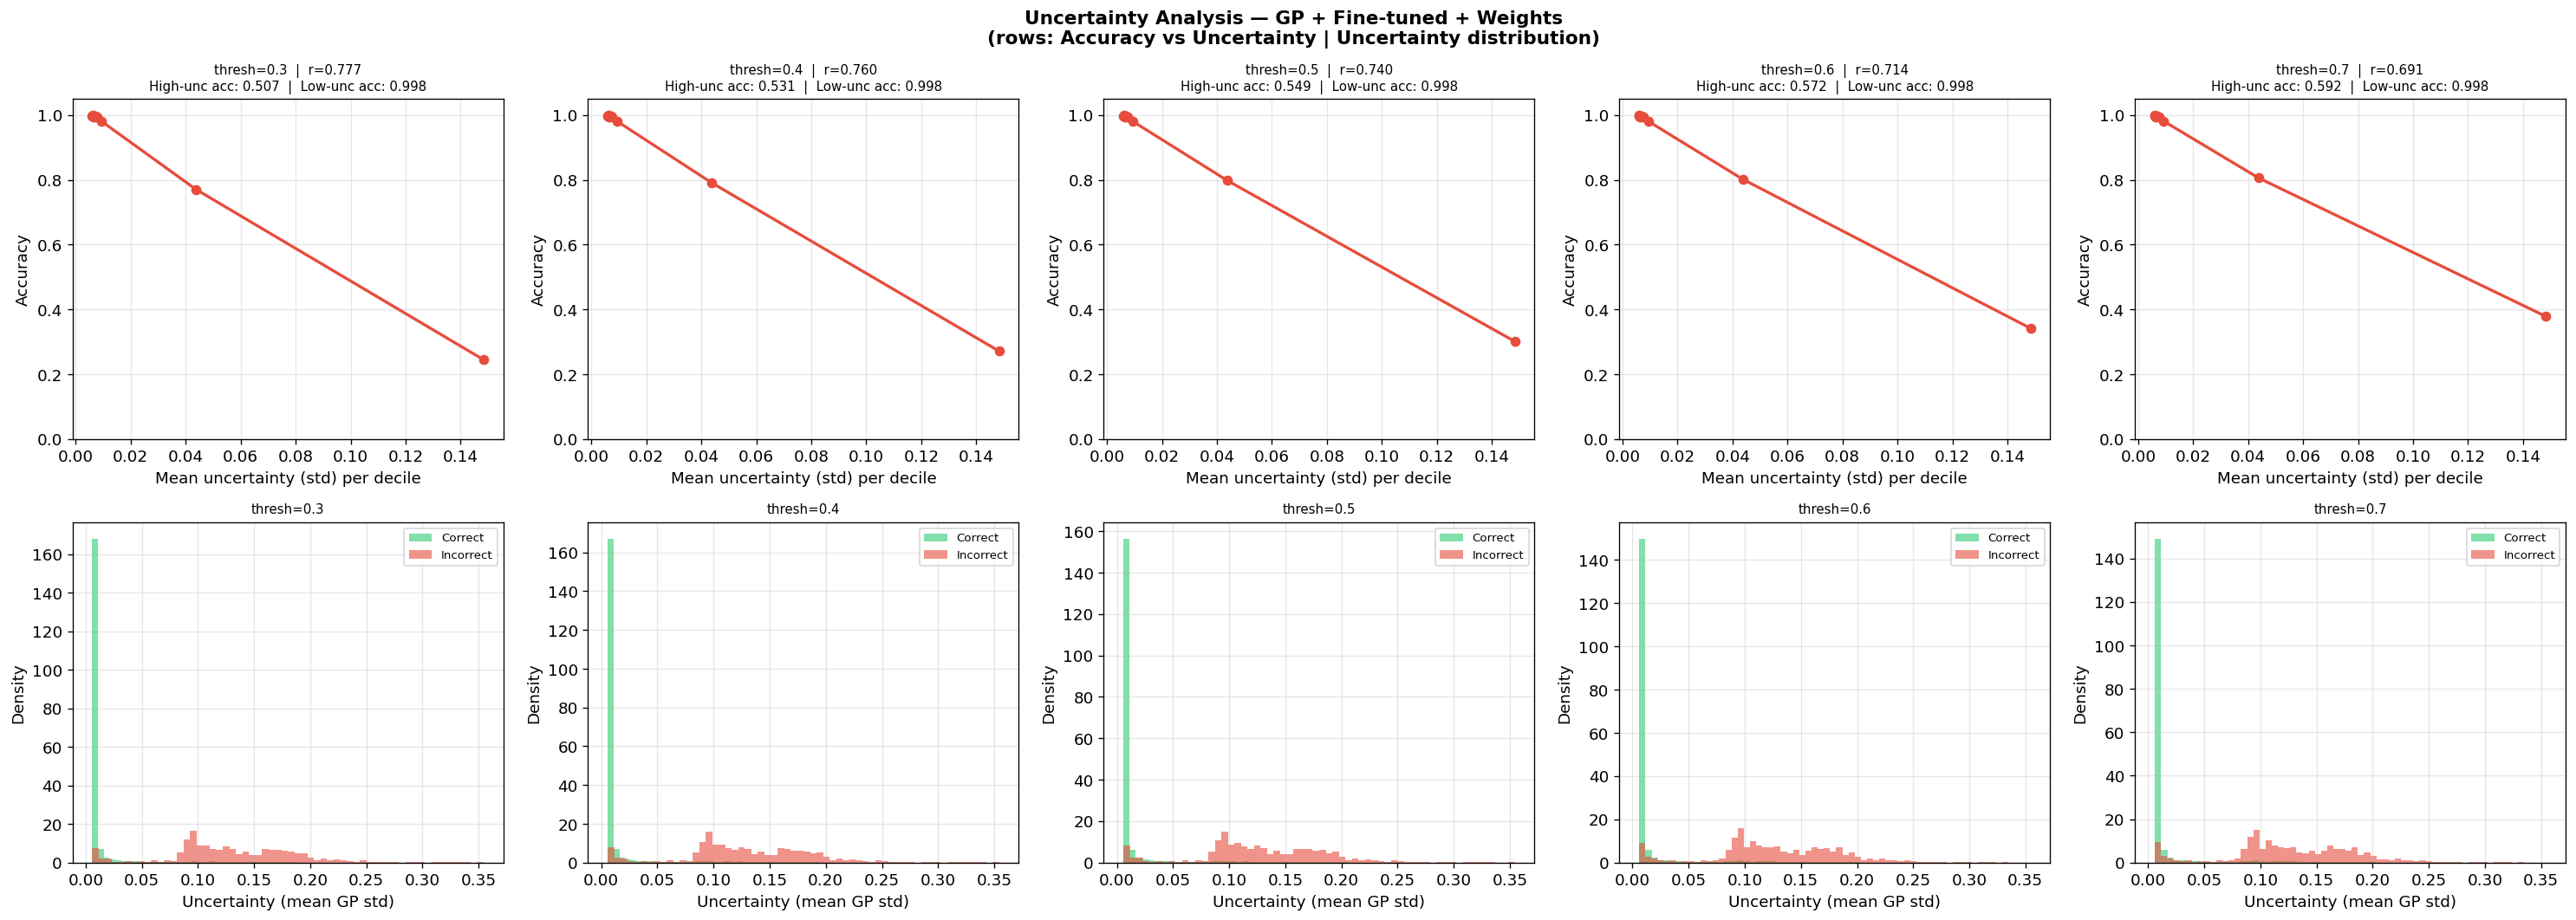

In [70]:
# ── Uncertainty vs Accuracy analysis across thresholds (GP Models) ────────

THRESH_LIST = [0.3, 0.4, 0.5, 0.6, 0.7]
N_BINS = 10

for model_key in GP_MODELS:
    probs_m = results[model_key]['probs']   # (N, 6)
    stds_m  = results[model_key]['stds']    # (N, 6)
    y_true_m = results[model_key]['y_true'] # (N, 6)
    
    uncertainties = stds_m.mean(axis=1)    # scalar uncertainty per sample

    fig, axes = plt.subplots(2, len(THRESH_LIST), figsize=(5 * len(THRESH_LIST), 9))
    fig.suptitle(f'Uncertainty Analysis — {MODEL_LABELS[model_key]}\n(rows: Accuracy vs Uncertainty | Uncertainty distribution)',
                 fontsize=13, fontweight='bold')

    for col, thresh in enumerate(THRESH_LIST):
        y_pred  = (probs_m >= thresh).astype(int)
        corrects = (y_pred == y_true_m).all(axis=1).astype(int)
        errors   = 1 - corrects

        # Sort by uncertainty
        order      = np.argsort(uncertainties)
        unc_sorted = uncertainties[order]
        corr_sorted = corrects[order]

        # Decile stats
        bins    = np.array_split(np.arange(len(unc_sorted)), N_BINS)
        bin_unc = [unc_sorted[b].mean() for b in bins]
        bin_acc = [corr_sorted[b].mean() for b in bins]

        r = np.corrcoef(uncertainties, errors)[0, 1]

        # Top/bottom 20%
        k = int(0.2 * len(corrects))
        acc_high = corrects[np.argsort(uncertainties)[-k:]].mean()
        acc_low  = corrects[np.argsort(uncertainties)[:k]].mean()

        # ── Row 0: Accuracy vs uncertainty decile ─────────────────────────
        ax0 = axes[0, col]
        ax0.plot(bin_unc, bin_acc, 'o-', color='#e74c3c', linewidth=2)
        ax0.set_xlabel('Mean uncertainty (std) per decile')
        ax0.set_ylabel('Accuracy')
        ax0.set_title(f'thresh={thresh}  |  r={r:.3f}\n'
                      f'High-unc acc: {acc_high:.3f}  |  Low-unc acc: {acc_low:.3f}',
                      fontsize=9)
        ax0.set_ylim(0, 1.05)
        ax0.grid(alpha=0.3)

        # ── Row 1: Uncertainty distribution correct vs incorrect ──────────
        ax1 = axes[1, col]
        ax1.hist(uncertainties[corrects == 1], bins=60, alpha=0.6,
                 label='Correct',   color='#2ecc71', density=True)
        ax1.hist(uncertainties[corrects == 0], bins=60, alpha=0.6,
                 label='Incorrect', color='#e74c3c', density=True)
        ax1.set_xlabel('Uncertainty (mean GP std)')
        ax1.set_ylabel('Density')
        ax1.set_title(f'thresh={thresh}', fontsize=9)
        ax1.legend(fontsize=8)
        ax1.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'images/uncertainty_vs_threshold_{model_key}.pdf', bbox_inches='tight')
    plt.show()

### Adversarial attacks

In [90]:
import re
# ── Attack functions ──────────────────────────────────────────────────────
def leet_speak(text):
    """l33tspeak: replace letters with visually similar digits."""
    return text.translate(str.maketrans('aeiost', '431057'))

def add_spaces(text):
    """Insert spaces between every character of long words."""
    return ' '.join(' '.join(w) if len(w) > 4 else w for w in text.split())

def unicode_homoglyphs(text):
    """Replace Latin letters with visually identical Cyrillic characters."""
    return text.translate(str.maketrans('aeoi', 'аеоі'))

def add_typos(text, rate=0.12, seed=42):
    """Randomly duplicate or drop characters."""
    rng    = random.Random(seed)
    result = []
    for ch in text:
        r = rng.random()
        if r < rate / 2:
            pass                      # drop
        elif r < rate:
            result.extend([ch, ch])   # duplicate
        else:
            result.append(ch)
    return ''.join(result)

def blank_noise(text, rate=0.10, seed=42):
    """Replace random words with [UNK] tokens."""
    rng   = random.Random(seed)
    words = text.split()
    return ' '.join('[UNK]' if rng.random() < rate else w for w in words)

def punct_noise(text):
    """Intercalate dots between pairs of word characters."""
    return re.sub(r'(\w)(\w)', r'\1.\2', text)

def neutral_prefix(text):
    """Prepend an innocuous phrase to dilute toxicity signal."""
    return 'In my humble opinion, ' + text

TRANSFORMS = {
    'leet_speak':       leet_speak,
    'add_spaces':       add_spaces,
    'homoglyphs':       unicode_homoglyphs,
    'typos':            add_typos,
    'punct_noise':      punct_noise,
    "prefix": neutral_prefix
}

print(f"Defined {len(TRANSFORMS)} attack transforms: {list(TRANSFORMS.keys())}")

Defined 6 attack transforms: ['leet_speak', 'add_spaces', 'homoglyphs', 'typos', 'punct_noise', 'prefix']


In [91]:
# ── Build adversarial corpus ──────────────────────────────────────────────
# Use 2 most uncertain samples per label-combo (reuse the GP_FT combos for fairness)
# We recompute combos from GP_FT predictions

combos_ft = defaultdict(list)
probs_ft_arr  = results['GP_FT']['probs']
stds_ft_arr   = results['GP_FT']['stds']
y_true_arr    = results['GP_FT']['y_true']

for idx in range(len(test_set)):
    true_combo = tuple(int(x) for x in y_true_arr[idx])
    text = tokenizer_gp_ft.decode(test_set[idx]['input_ids'], skip_special_tokens=True)
    combos_ft[true_combo].append({
        'index':      idx,
        'text':       text,
        'combo_true': list(true_combo),
        'probs':      probs_ft_arr[idx].tolist(),
        'uncertainty': float(stds_ft_arr[idx].mean()),
    })

# Top-2 most uncertain per combo
adv_corpus = []
for combo, samples in combos_ft.items():
    top2 = sorted(samples, key=lambda x: x['uncertainty'], reverse=True)[:2]
    for s in top2:
        adv_corpus.append(s)

print(f"Adversarial corpus: {len(adv_corpus)} samples across {len(combos_ft)} label combos")

Adversarial corpus: 51 samples across 29 label combos


In [92]:
def predict_model(model_key, text):
    """Returns predicted label vector (at opt threshold) for a given model."""
    if model_key == 'DISTILBERT':
        result = predict_with_scores(
            model_distilbert, tokenizer_distilbert, text, id2label, device=device, threshold=0.5
        )
        probs = np.array([p for _, p in result['raw_probs']])
        stds  = np.zeros(len(LABEL_COLS))
    else:
        m_map = {'GP': (model_gp, tokenizer_gp),
                 'GP_FT': (model_gp_ft, tokenizer_gp_ft),
                 'GP_FT_W': (model_gp_ft_w, tokenizer_gp_ft_w)}
        m, tok = m_map[model_key]
        result = predict_with_uncertainty(m, tok, text, id2label, device=device, threshold=0.5)
        probs  = np.array([p for _, p, _ in result['all_scores']])
        stds   = np.array([s for _, _, s in result['all_scores']])

    # Apply per-label optimal threshold
    y_pred = np.array([
        int(probs[i] >= threshold_results[model_key][lbl]['best_threshold'])
        for i, lbl in enumerate(LABEL_COLS)
    ])
    return probs, stds, y_pred


# ── Evaluate all attacks × all models ─────────────────────────────────────
attack_summary = {model_key: {t: {'flips': [], 'accs': []} for t in TRANSFORMS}
                  for model_key in results}

for entry in tqdm.tqdm(adv_corpus, desc='Adversarial eval'):
    orig_text  = entry['text']
    true_labels = np.array(entry['combo_true'])

    # Original predictions for each model
    orig_preds = {}
    for model_key in results:
        _, _, yp = predict_model(model_key, orig_text)
        orig_preds[model_key] = yp

    for t_name, t_fn in TRANSFORMS.items():
        perturbed = t_fn(orig_text)
        for model_key in results:
            _, _, yp_adv = predict_model(model_key, perturbed)
            flipped = not np.array_equal(yp_adv, orig_preds[model_key])
            correct = np.array_equal(yp_adv, true_labels)
            attack_summary[model_key][t_name]['flips'].append(int(flipped))
            attack_summary[model_key][t_name]['accs'].append(int(correct))

print("Adversarial evaluation complete.")

Adversarial eval: 100%|██████████| 51/51 [01:07<00:00,  1.33s/it]

Adversarial evaluation complete.


In [93]:
# ── Compute flip rate and accuracy per attack & model ─────────────────────
robustness_rows = []
for model_key in results:
    for t_name in TRANSFORMS:
        flips = attack_summary[model_key][t_name]['flips']
        accs  = attack_summary[model_key][t_name]['accs']
        robustness_rows.append({
            'Model':     MODEL_LABELS[model_key],
            'model_key': model_key,
            'Attack':    t_name,
            'Flip Rate': np.mean(flips),
            'Accuracy':  np.mean(accs),
        })

df_rob = pd.DataFrame(robustness_rows)
print("=== Robustness Summary ===")
display(df_rob.pivot_table(index='Attack', columns='Model', values=['Flip Rate', 'Accuracy'])
        .style.format("{:.3f}"))

=== Robustness Summary ===


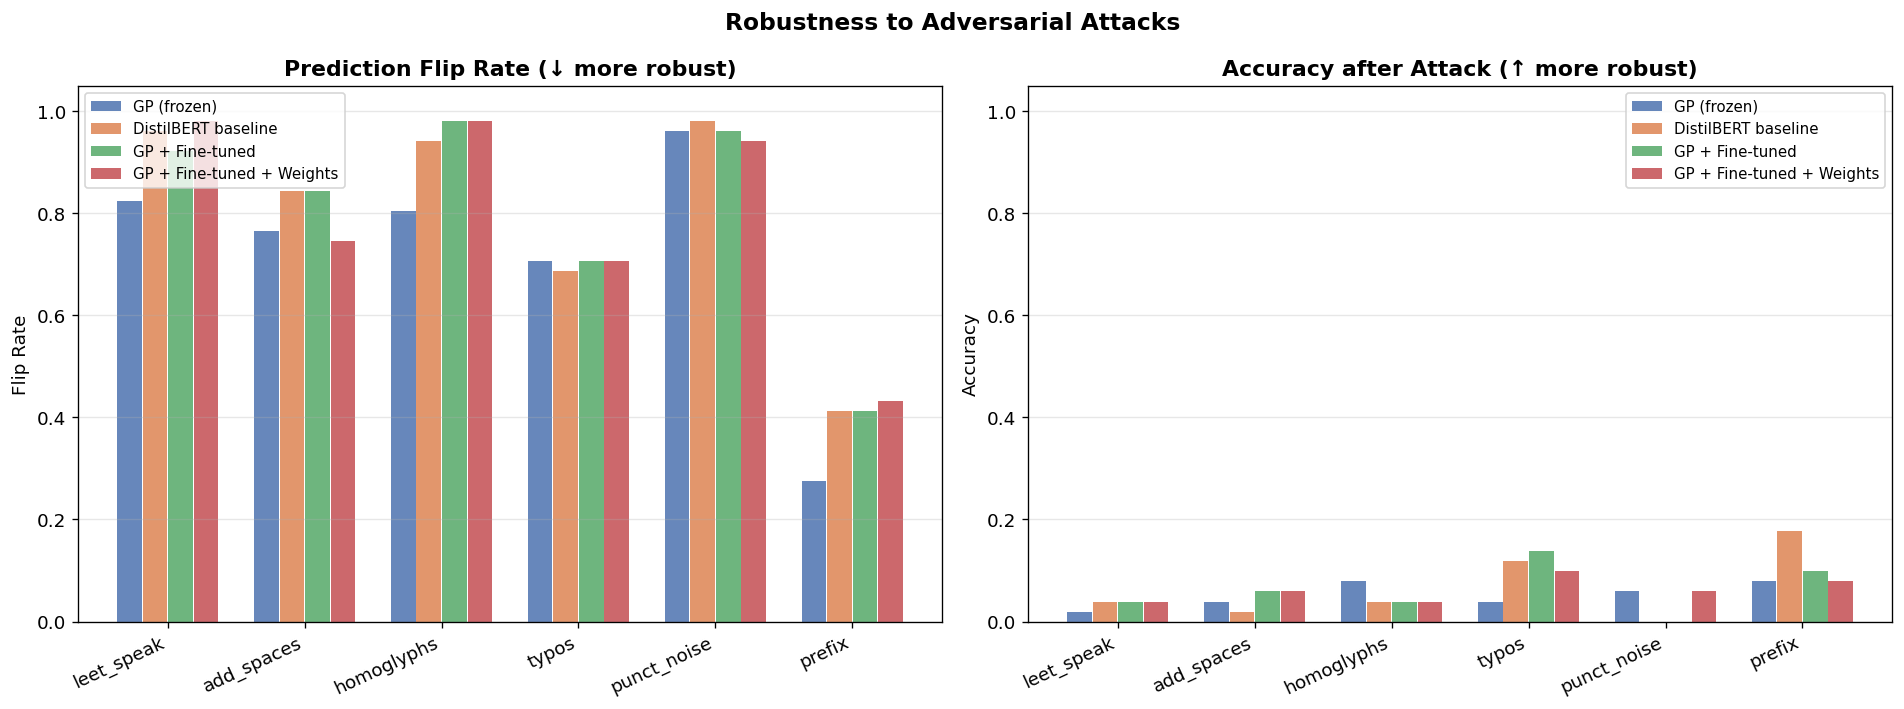

In [94]:
attacks = list(TRANSFORMS.keys())
x = np.arange(len(attacks))
width = 0.18
offsets = np.linspace(-0.28, 0.28, len(results))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ['Flip Rate', 'Accuracy'],
                              ['Prediction Flip Rate (↓ more robust)', 'Accuracy after Attack (↑ more robust)']):
    for offset, model_key in zip(offsets, results):
        values = [df_rob[(df_rob['model_key'] == model_key) & (df_rob['Attack'] == t)][metric].values[0]
                  for t in attacks]
        ax.bar(x + offset, values, width, label=MODEL_LABELS[model_key],
               color=PALETTE[model_key], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(attacks, rotation=25, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Robustness to Adversarial Attacks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/robustness_attacks.pdf', bbox_inches='tight')
plt.show()

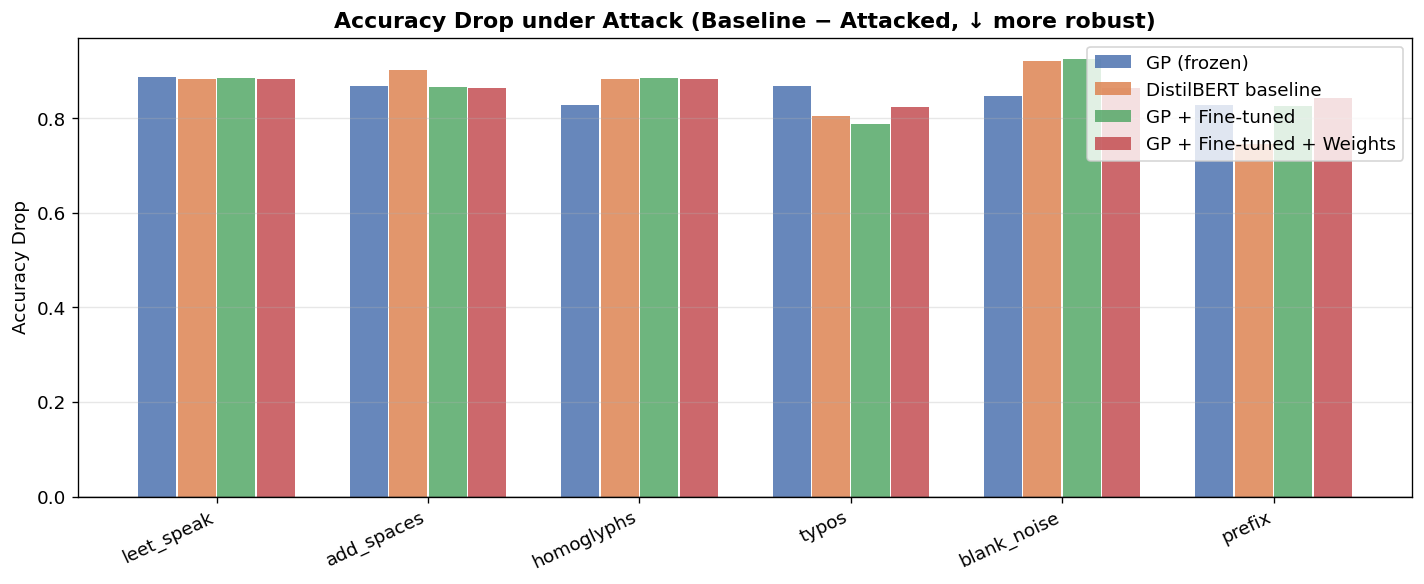

In [89]:
# Baseline accuracy (no attack) per model
baseline_acc = {k: all_metrics[k]['Exact Match Accuracy (opt)'] for k in results}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(attacks))
offsets = np.linspace(-0.28, 0.28, len(results))

for offset, model_key in zip(offsets, results):
    drops = []
    for t in attacks:
        adv_acc = df_rob[(df_rob['model_key'] == model_key) & (df_rob['Attack'] == t)]['Accuracy'].values[0]
        drop = baseline_acc[model_key] - adv_acc
        drops.append(drop)
    ax.bar(x + offset, drops, 0.18, label=MODEL_LABELS[model_key],
           color=PALETTE[model_key], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(attacks, rotation=25, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Accuracy Drop under Attack (Baseline − Attacked, ↓ more robust)', fontweight='bold')
ax.set_ylabel('Accuracy Drop')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/accuracy_drop.pdf', bbox_inches='tight')
plt.show()

### More plots

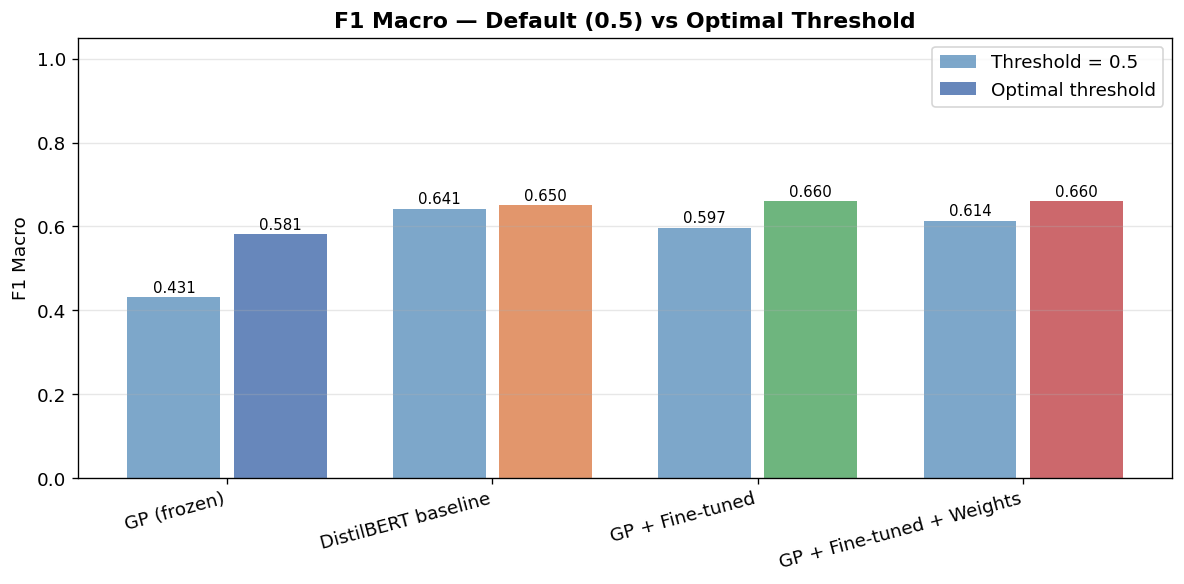

In [77]:
model_names_short = [MODEL_LABELS[k] for k in results]
f1_05  = [all_metrics[k]['F1 Macro (0.5)']  for k in results]
f1_opt = [all_metrics[k]['F1 Macro (opt)']  for k in results]

x = np.arange(len(model_names_short))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, f1_05,  0.35, label='Threshold = 0.5', alpha=0.7, color='steelblue')
bars2 = ax.bar(x + 0.2, f1_opt, 0.35, label='Optimal threshold', alpha=0.85,
               color=[PALETTE[k] for k in results])

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names_short, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Macro')
ax.set_title('F1 Macro — Default (0.5) vs Optimal Threshold', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/f1_threshold_comparison.pdf', bbox_inches='tight')
plt.show()